# Expert task: DQN and Double DQN on CartPole-v1

This notebook completes the expert-level Reinforcement Learning exercise. It implements DQN and Double DQN with Replay Buffer, Target Network, epsilon decay, and complete learning-curve diagnostics.

## 1. Imports and output folder

In [1]:
import os
import random
from collections import deque, namedtuple
from dataclasses import dataclass
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

OUTPUT_DIR = Path('../output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cpu


## 2. Environment inspection

In [2]:
env = gym.make('CartPole-v1')
obs, info = env.reset(seed=SEED)
env.action_space.seed(SEED)

print('Observation space:', env.observation_space)
print('Action space:', env.action_space)
print('Initial observation:', obs)
print('Observation variables: cart position, cart velocity, pole angle, pole angular velocity')
env.close()

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Initial observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Observation variables: cart position, cart velocity, pole angle, pole angular velocity


## 3. Training configuration

In [3]:
@dataclass
class DQNConfig:
    env_name: str = 'CartPole-v1'
    episodes: int = 700
    max_steps: int = 500
    gamma: float = 0.99
    learning_rate: float = 5e-4
    batch_size: int = 128
    replay_buffer_size: int = 10000
    learning_starts: int = 1000
    target_update_steps: int = 100
    epsilon_start: float = 1.0
    epsilon_end: float = 0.05
    epsilon_decay: float = 0.992
    solved_threshold: float = 195.0
    smoothing_window: int = 50
    stable_window: int = 10
    hidden_dim: int = 64
    gradient_clip: float = 10.0

config = DQNConfig()
print(config)

DQNConfig(env_name='CartPole-v1', episodes=700, max_steps=500, gamma=0.99, learning_rate=0.0005, batch_size=128, replay_buffer_size=10000, learning_starts=1000, target_update_steps=100, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.992, solved_threshold=195.0, smoothing_window=50, stable_window=10, hidden_dim=64, gradient_clip=10.0)


## 4. Neural network and replay buffer

In [4]:
class QNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x):
        return self.net(x)

Transition = namedtuple('Transition', ['state', 'action', 'reward', 'next_state', 'done'])

class ReplayBuffer:
    def __init__(self, capacity: int):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.memory.append(Transition(state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.memory, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        return len(self.memory)

## 5. Action selection and diagnostics

In [5]:
def epsilon_by_episode(episode: int, cfg: DQNConfig) -> float:
    return max(cfg.epsilon_end, cfg.epsilon_start * (cfg.epsilon_decay ** episode))

def select_action(state, policy_net, epsilon: float, action_dim: int):
    if random.random() < epsilon:
        return random.randrange(action_dim)
    state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        return int(policy_net(state_tensor).argmax(dim=1).item())

def moving_average(values, window: int):
    return pd.Series(values, dtype='float64').rolling(window=window, min_periods=1).mean().to_numpy()

def first_stable_episode(smoothed_rewards, threshold: float, stable_window: int):
    smoothed_rewards = np.asarray(smoothed_rewards)
    for idx in range(len(smoothed_rewards) - stable_window + 1):
        if np.all(smoothed_rewards[idx:idx + stable_window] >= threshold):
            return idx
    candidates = np.where(smoothed_rewards >= threshold)[0]
    if len(candidates) > 0:
        return int(candidates[0])
    return None

## 6. Optimization step

In [6]:
def optimize_model(policy_net, target_net, optimizer, replay_buffer, cfg: DQNConfig, double_dqn: bool):
    if len(replay_buffer) < max(cfg.batch_size, cfg.learning_starts):
        return None

    transitions = replay_buffer.sample(cfg.batch_size)

    states = torch.tensor(np.array(transitions.state), dtype=torch.float32, device=DEVICE)
    actions = torch.tensor(transitions.action, dtype=torch.long, device=DEVICE).unsqueeze(1)
    rewards = torch.tensor(transitions.reward, dtype=torch.float32, device=DEVICE).unsqueeze(1)
    next_states = torch.tensor(np.array(transitions.next_state), dtype=torch.float32, device=DEVICE)
    dones = torch.tensor(transitions.done, dtype=torch.float32, device=DEVICE).unsqueeze(1)

    current_q_values = policy_net(states).gather(1, actions)

    with torch.no_grad():
        if double_dqn:
            next_actions = policy_net(next_states).argmax(dim=1, keepdim=True)
            next_q_values = target_net(next_states).gather(1, next_actions)
        else:
            next_q_values = target_net(next_states).max(dim=1, keepdim=True)[0]

        target_q_values = rewards + cfg.gamma * next_q_values * (1.0 - dones)

    loss = F.smooth_l1_loss(current_q_values, target_q_values)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), cfg.gradient_clip)
    optimizer.step()

    return float(loss.item())

## 7. Training function

In [7]:
def train_agent(cfg: DQNConfig, double_dqn: bool = False, seed_offset: int = 0):
    env = gym.make(cfg.env_name)
    env.action_space.seed(SEED + seed_offset)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    policy_net = QNetwork(state_dim, action_dim, cfg.hidden_dim).to(DEVICE)
    target_net = QNetwork(state_dim, action_dim, cfg.hidden_dim).to(DEVICE)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.AdamW(policy_net.parameters(), lr=cfg.learning_rate, amsgrad=True)
    replay_buffer = ReplayBuffer(cfg.replay_buffer_size)

    rewards = []
    epsilons = []
    losses = []
    global_step = 0

    label = 'Double DQN' if double_dqn else 'DQN'

    for episode in range(cfg.episodes):
        state, info = env.reset(seed=SEED + seed_offset + episode)
        epsilon = epsilon_by_episode(episode, cfg)
        epsilons.append(epsilon)
        episode_reward = 0.0

        for step in range(cfg.max_steps):
            action = select_action(state, policy_net, epsilon, action_dim)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            replay_buffer.push(state, action, reward, next_state, done)
            loss = optimize_model(policy_net, target_net, optimizer, replay_buffer, cfg, double_dqn)
            if loss is not None:
                losses.append(loss)

            state = next_state
            episode_reward += reward
            global_step += 1

            if global_step % cfg.target_update_steps == 0:
                target_net.load_state_dict(policy_net.state_dict())

            if done:
                break

        rewards.append(episode_reward)

        if (episode + 1) % 50 == 0:
            recent_mean = np.mean(rewards[-cfg.smoothing_window:])
            print(f'{label} | episode {episode + 1:4d} | mean reward {recent_mean:7.2f} | epsilon {epsilon:5.3f}')

    env.close()

    smoothed = moving_average(rewards, cfg.smoothing_window)
    stable_episode = first_stable_episode(smoothed, cfg.solved_threshold, cfg.stable_window)

    return {
        'label': label,
        'rewards': rewards,
        'smoothed_rewards': smoothed,
        'epsilons': epsilons,
        'losses': losses,
        'stable_episode': stable_episode,
        'final_mean_reward': float(np.mean(rewards[-cfg.smoothing_window:])),
        'best_smoothed_reward': float(np.max(smoothed)),
        'model': policy_net,
    }

## 8. Train DQN

In [8]:
dqn_result = train_agent(config, double_dqn=False, seed_offset=0)

dqn_rewards = dqn_result['rewards']
dqn_smoothed_rewards = dqn_result['smoothed_rewards']
dqn_epsilons = dqn_result['epsilons']
dqn_stable_episode = dqn_result['stable_episode']

print('DQN episodes:', len(dqn_rewards))
print('DQN final MA50:', dqn_result['final_mean_reward'])
print('DQN best MA50:', dqn_result['best_smoothed_reward'])
print('DQN stable episode:', dqn_stable_episode)

DQN | episode   50 | mean reward   20.28 | epsilon 0.675
DQN | episode  100 | mean reward   43.60 | epsilon 0.451
DQN | episode  150 | mean reward   84.58 | epsilon 0.302
DQN | episode  200 | mean reward   58.80 | epsilon 0.202
DQN | episode  250 | mean reward   75.00 | epsilon 0.135
DQN | episode  300 | mean reward   73.52 | epsilon 0.091
DQN | episode  350 | mean reward   87.64 | epsilon 0.061
DQN | episode  400 | mean reward  106.18 | epsilon 0.050
DQN | episode  450 | mean reward  273.70 | epsilon 0.050
DQN | episode  500 | mean reward  176.48 | epsilon 0.050
DQN | episode  550 | mean reward  134.06 | epsilon 0.050
DQN | episode  600 | mean reward  202.72 | epsilon 0.050
DQN | episode  650 | mean reward  343.60 | epsilon 0.050
DQN | episode  700 | mean reward  274.68 | epsilon 0.050
DQN episodes: 700
DQN final MA50: 274.68
DQN best MA50: 398.24
DQN stable episode: 425


## 9. Plot DQN learning curve with epsilon decay

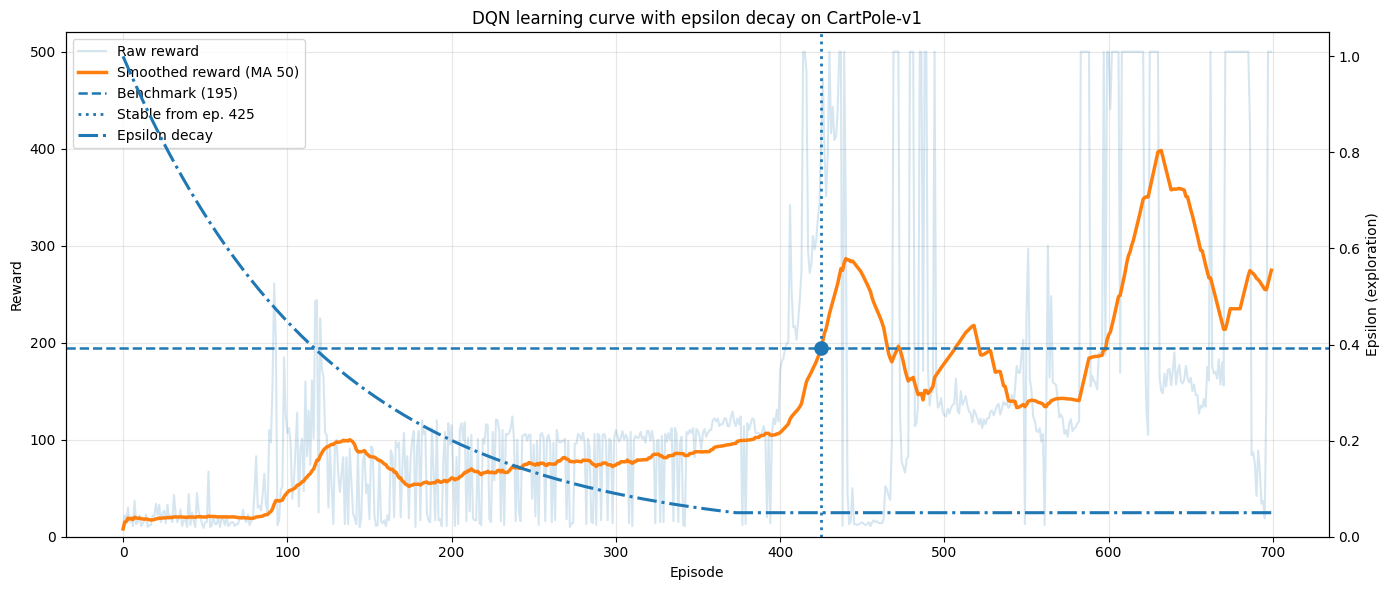

In [9]:
fig, ax1 = plt.subplots(figsize=(14, 6))

episodes = np.arange(len(dqn_rewards))
ax1.plot(episodes, dqn_rewards, alpha=0.18, label='Raw reward')
ax1.plot(episodes, dqn_smoothed_rewards, linewidth=2.5, label=f'Smoothed reward (MA {config.smoothing_window})')
ax1.axhline(config.solved_threshold, linestyle='--', linewidth=1.8, label=f'Benchmark ({int(config.solved_threshold)})')

if dqn_stable_episode is not None:
    ax1.axvline(dqn_stable_episode, linestyle=':', linewidth=2.0, label=f'Stable from ep. {dqn_stable_episode}')
    ax1.scatter([dqn_stable_episode], [config.solved_threshold], s=90, zorder=5)

ax1.set_title('DQN learning curve with epsilon decay on CartPole-v1')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Reward')
ax1.set_ylim(0, 520)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(episodes, dqn_epsilons, linestyle='-.', linewidth=2.2, label='Epsilon decay')
ax2.set_ylabel('Epsilon (exploration)')
ax2.set_ylim(0, 1.05)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dqn_learning_curve_with_epsilon.png', dpi=200, bbox_inches='tight')
plt.show()

## 10. Train Double DQN

In [10]:
ddqn_result = train_agent(config, double_dqn=True, seed_offset=10000)

ddqn_rewards = ddqn_result['rewards']
ddqn_smoothed_rewards = ddqn_result['smoothed_rewards']
ddqn_epsilons = ddqn_result['epsilons']
ddqn_stable_episode = ddqn_result['stable_episode']

print('DDQN episodes:', len(ddqn_rewards))
print('DDQN final MA50:', ddqn_result['final_mean_reward'])
print('DDQN best MA50:', ddqn_result['best_smoothed_reward'])
print('DDQN stable episode:', ddqn_stable_episode)

Double DQN | episode   50 | mean reward   19.40 | epsilon 0.675
Double DQN | episode  100 | mean reward   20.60 | epsilon 0.451
Double DQN | episode  150 | mean reward   81.18 | epsilon 0.302
Double DQN | episode  200 | mean reward  116.62 | epsilon 0.202
Double DQN | episode  250 | mean reward  156.16 | epsilon 0.135
Double DQN | episode  300 | mean reward  101.40 | epsilon 0.091
Double DQN | episode  350 | mean reward  109.42 | epsilon 0.061
Double DQN | episode  400 | mean reward   89.44 | epsilon 0.050
Double DQN | episode  450 | mean reward   95.76 | epsilon 0.050
Double DQN | episode  500 | mean reward   98.44 | epsilon 0.050
Double DQN | episode  550 | mean reward   76.28 | epsilon 0.050
Double DQN | episode  600 | mean reward  197.52 | epsilon 0.050
Double DQN | episode  650 | mean reward  447.62 | epsilon 0.050
Double DQN | episode  700 | mean reward  488.60 | epsilon 0.050
DDQN episodes: 700
DDQN final MA50: 488.6
DDQN best MA50: 500.0
DDQN stable episode: 599


## 11. Plot DQN vs Double DQN

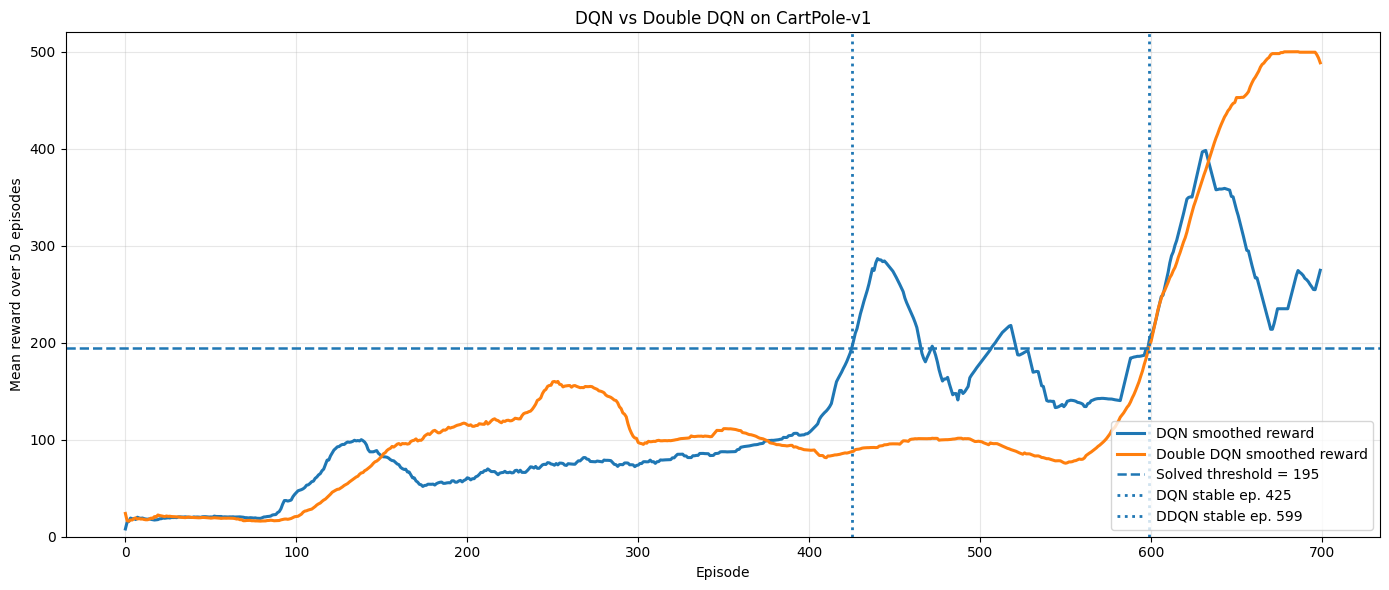

In [11]:
fig, ax1 = plt.subplots(figsize=(14, 6))

episodes = np.arange(len(dqn_rewards))
ax1.plot(episodes, dqn_smoothed_rewards, linewidth=2.2, label='DQN smoothed reward')
ax1.plot(episodes, ddqn_smoothed_rewards, linewidth=2.2, label='Double DQN smoothed reward')
ax1.axhline(config.solved_threshold, linestyle='--', linewidth=1.8, label=f'Solved threshold = {int(config.solved_threshold)}')

if dqn_stable_episode is not None:
    ax1.axvline(dqn_stable_episode, linestyle=':', linewidth=2.0, label=f'DQN stable ep. {dqn_stable_episode}')
if ddqn_stable_episode is not None:
    ax1.axvline(ddqn_stable_episode, linestyle=':', linewidth=2.0, label=f'DDQN stable ep. {ddqn_stable_episode}')

ax1.set_title('DQN vs Double DQN on CartPole-v1')
ax1.set_xlabel('Episode')
ax1.set_ylabel(f'Mean reward over {config.smoothing_window} episodes')
ax1.set_ylim(0, 520)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dqn_vs_double_dqn_complete.png', dpi=200, bbox_inches='tight')
plt.show()

## 12. Save result tables

In [12]:
results_df = pd.DataFrame({
    'episode': np.arange(config.episodes),
    'dqn_reward': dqn_rewards,
    'dqn_smoothed_reward': dqn_smoothed_rewards,
    'dqn_epsilon': dqn_epsilons,
    'ddqn_reward': ddqn_rewards,
    'ddqn_smoothed_reward': ddqn_smoothed_rewards,
    'ddqn_epsilon': ddqn_epsilons,
})

summary_df = pd.DataFrame([
    {
        'agent': 'DQN',
        'episodes': len(dqn_rewards),
        'final_ma50': dqn_result['final_mean_reward'],
        'best_ma50': dqn_result['best_smoothed_reward'],
        'stable_episode': dqn_stable_episode,
        'solved_threshold': config.solved_threshold,
    },
    {
        'agent': 'Double DQN',
        'episodes': len(ddqn_rewards),
        'final_ma50': ddqn_result['final_mean_reward'],
        'best_ma50': ddqn_result['best_smoothed_reward'],
        'stable_episode': ddqn_stable_episode,
        'solved_threshold': config.solved_threshold,
    },
])

results_df.to_csv(OUTPUT_DIR / 'dqn_ddqn_cartpole_complete_rewards.csv', index=False)
summary_df.to_csv(OUTPUT_DIR / 'dqn_ddqn_cartpole_complete_summary.csv', index=False)

display(summary_df)

,agent,episodes,final_ma50,best_ma50,stable_episode,solved_threshold
0,DQN,700,274.68,398.24,425,195.0
1,Double DQN,700,488.60,500.00,599,195.0


## 13. Interpretation

In [13]:
if dqn_stable_episode is None:
    print('DQN did not reach a stable solved phase within the configured number of episodes.')
else:
    print(f'DQN reached the solved threshold from episode {dqn_stable_episode}.')

if ddqn_stable_episode is None:
    print('Double DQN did not reach a stable solved phase within the configured number of episodes.')
else:
    print(f'Double DQN reached the solved threshold from episode {ddqn_stable_episode}.')

print('Saved files:')
print(OUTPUT_DIR / 'dqn_learning_curve_with_epsilon.png')
print(OUTPUT_DIR / 'dqn_vs_double_dqn_complete.png')
print(OUTPUT_DIR / 'dqn_ddqn_cartpole_complete_rewards.csv')
print(OUTPUT_DIR / 'dqn_ddqn_cartpole_complete_summary.csv')

DQN reached the solved threshold from episode 425.
Double DQN reached the solved threshold from episode 599.
Saved files:
..\output\dqn_learning_curve_with_epsilon.png
..\output\dqn_vs_double_dqn_complete.png
..\output\dqn_ddqn_cartpole_complete_rewards.csv
..\output\dqn_ddqn_cartpole_complete_summary.csv
